<div style="border:solid green 2px; padding: 20px"> <h1 style="color:green; margin-bottom:20px">Комментарий ревьюера v1</h1>

Николай, привет! Меня зовут Дмитрий, и я буду проверять твой проект. Предлагаю общаться на «ты» если ты не против 😊 Но если нет, то дай знать, и мы перейдем на "вы". 
    
Для своих комментариев я буду использовать цветовую разметку:

<div class="alert alert-success">
    <b>Успех:</b> все сделано правильно.
</div>
<div class="alert alert-warning">
    <b>Есть замечания:</b> так выделены небольшие замечания которые не критичны, но было бы здорово исправить. Если таких замечаний немного, то такой проект может быть принят.
</div>
<div class="alert alert-danger">
    <b>Нужно переделать:</b> есть замечания которые необходимо исправить или доделать для сдачи проекта.
</div>
    
Я буду поддерживать версионность комментариев, и при следующих итерациях я буду оставлять ячейки с новой версией v2 (v3 и.т.д.)
    
Если у тебя есть вопросы, замечания или отвечаешь на комментарии — пиши об этом. Мне будет легче отследить изменения, если ты выделишь свои комментарии: 
<div class="alert alert-info"> <b>Комментарий студента:</b></div>


<div style="border:solid green 2px; padding: 20px">
<b>Комментарий ревьюера v1:</b>
    
<b>Общее впечатление:</b> 
 
Отличная работа по разработке модели машинного обучения для задачи регрессии — прогнозирования спроса на аренду велосипедов! Ты продемонстрировал владение продвинутым инструментарием: грамотное использование sklearn Pipeline и ColumnTransformer, глубокий анализ зависимостей и автоматический подбор гиперпараметров с помощью Optuna.

Модель разработана с явным пониманием алгоритмов: ты правильно разделил предобработку для kNN (с масштабированием) и Деревьев решений, что критически важно для корректного сравнения. Структура ноутбука логична, код чист и воспроизводим, а выводы опираются на цифры. Особенно ценно, что ты провел честное сравнение с Baseline-моделью и доказал эффективность нелинейных подходов.
    
Осталось исправить совсем чуть-чуть для сдачи проекта (буду также рад исправлениям желтых:)
Буду ждать новую версию на повторную проверку 😇 Успехов!

</div>

# **Нелинейные модели против южной погоды**
<big>Модель предсказания загруженности велопроката в южных регионах России с помощью нелинейных моделей kNN и DecisionTree</big>

## Содержание
1. <a href="#intro">Введение</a>
1. <a href="#environment">Подготовка окружения</a>
1. <a href="#oldmodel">Оценка качества предоставленной линейной модели</a>
1. <a href="#eda">Исследовательский анализ данных</a>
1. <a href="#baseline">Обучение и оценка базовой модели</a>
1. <a href="#hyperparameters">Подбор гиперпараметров</a>
1. <a href="#final-model">Обучение финальной модели</a>
1. <a href="#final-report">Выводы по выбору модели</a>
1. <a href="#save-model">Подготовка артефактов модели для внедрения</a>


<a id="intro"></a>
## Введение

### Бизнес-контекст

Компания BikeSouth - оператор городского велопроката на черноморском побережье России - стремится улучшить прогнозирование почасового спроса на велосипеды. Ранее использовалась линейная регрессия, но она не справлялась с нелинейными зависимостями между погодными факторами и спросом. Точные прогнозы позволят оптимизировать распределение велосипедов по станциям и улучшить клиентский опыт, избегая простоев и дефицита.

### Цель исследования

Построить модель машинного обучения, которая по совокупности погодных, временных и календарных признаков будет прогнозировать почасовой спрос на велосипеды (количество арендованных велосипедов в час).

### Постановка задачи машинного обучения

Целевая переменная - `Rented Bike Count` - количество велосипедов, арендованных за конкретный час. Переменная является числовой, следовательно, мы имеем дело с задачей **обучения с учителем** в постановке **регрессии**.

Признаковое пространство включает:
- **Погодные характеристики**: температура, влажность, скорость ветра, видимость, точка росы, солнечная радиация, осадки, снегопад;
- **Календарные признаки**: время года (`Seasons`), выходной/праздник (`Holiday`), функциональный день (`Functioning Day`);
- **Временные признаки**: период суток (`Time_Period` - Night, Morning, Daytime, Evening, Late Evening), закодированный в виде бинарных колонок с базовым состоянием Daytime.

Компания предоставила два датасета: `ds_s14_train_data.csv` для обучения и валидации, `ds_s14_test_data.csv` - исключительно для финальной оценки качества. Тестовая выборка не используется на этапах обучения и подбора гиперпараметров.

В качестве моделей используем:
- **Линейная регрессия** - как baseline-модель;
- **Метод k ближайших соседей (kNN)**;
- **Дерево решений (Decision Tree)**.

Подбор гиперпараметров kNN и дерева решений выполняется с помощью библиотеки **Optuna**.

**Метрики качества**

Основная метрика - **MAE (Mean Absolute Error)**: показывает, на сколько велосипедов в среднем ошибается прогноз за час, что имеет прямую бизнес-интерпретацию. Вспомогательные метрики:
- **RMSE (Root Mean Squared Error)** - для оценки чувствительности к крупным ошибкам в пиковые часы;
- **R² (коэффициент детерминации)** - для оценки доли объяснённой дисперсии таргета.

Лучшая модель должна демонстрировать значимое улучшение по MAE и R² относительно baseline на тестовой выборке для обоснования перехода на новый алгоритм.


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Комментарий ревьюера v1:</b>
    
Введение написано отлично. Ты точно сформулировал бизнес-цель проекта для BikeSouth. 
    
Описание данных получилось структурированным и понятным. 

<a id="environment"></a>

## Подготовка окружения

In [41]:
! rm requirements.txt

In [42]:
from pathlib import Path

requirements_file = Path('requirements.txt')
requirements = [
    'phik==0.12.5',
    'joblib==1.5.3',
    'scikit-learn==1.6.1',
    'seaborn==0.13.2',
    'optuna==4.8.0',
    'plotly==6.7.0',
    'humanfriendly==10.0',
    'numpy==1.26.4',
]
if not requirements_file.exists():
    with open(requirements_file, 'w') as f:
        f.write('\n'.join(requirements))
        print(f'{requirements_file} created')
else:
    print(f'{requirements_file} exists')

print('Установка зависимостей...')
!pip install -r requirements.txt
print('Зависимости успешно установлены!')


requirements.txt created
Установка зависимостей...
Зависимости успешно установлены!


In [43]:
import os
import requests
from datetime import datetime
import optuna
import plotly
import joblib
from phik import phik_matrix

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import FunctionTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_validate, cross_val_score, KFold
from sklearn.metrics import (
    root_mean_squared_error,
    mean_squared_error,
    r2_score,
    mean_absolute_error,
    make_scorer,
)

from humanfriendly import format_size


Подготовка параметров тетрадки и утилит:

In [44]:
TARGET_COL_NAME = 'Rented Bike Count'
RANDOM_STATE = 153
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None) # выводить все колонки
pd.set_option('display.max_colwidth', 500) # выводить больше символов в ячейке

#### Заргузка ресурсов
class ResourceLoader:
    """
    Класс для безопасной загрузки ресурсов по http: датасет и произвольный файл.
    Если файл уже был скачан ранее и сохранен в локальной файловой системе, то
    загрузка из удаленного источника не производится.

    Для загрузки датасета: load_dataset(dataset_url, local_file, local_path='datasets'): dataframe
    Для загрузки файла: load_resource(resource_url, local_path, local_file): path
    """

    def __init__(self):
        pass

    def load_resource(self, resource_url, local_path, local_file):
        local_resource_file = f'{local_path}/{local_file}'
        if os.path.exists(local_resource_file):
            print(f'Файл {local_resource_file} уже существует')
            return local_resource_file

        os.makedirs(local_path, exist_ok=True)
        print(f'Файл не найден. Загружаем файл из {resource_url}')
        response = requests.get(resource_url)
        if response.status_code == 200:
            with open(local_resource_file, 'wb') as f:
                f.write(response.content)
            file_size = format_size(os.path.getsize(local_resource_file))
            print(f'Файл успешно загружен в {local_resource_file},',
                  f'размер файла: {file_size}')
            return local_resource_file
        else:
            raise NetworkError(f'Ошибка при загрузке файла: {response.status_code}')


    def load_dataset(
        self,
        dataset_url,
        local_file,
        local_path='datasets',
        sep=',',
        decimal='.'
    ):
        local_dataset_file = f'{local_path}/{local_file}'
        remote_dataset_url = dataset_url
        def read_dataset_csv():
            return pd.read_csv(local_dataset_file, sep=sep, decimal=decimal)

        try:
            df = read_dataset_csv()
            print(f'Датасет успешно загружен из {local_dataset_file}')
        except FileNotFoundError:
            self.load_resource(remote_dataset_url, local_path, local_file)
            df = read_dataset_csv()

        print(f'Размер загруженного датасета: {df.shape[0]} строк, {df.shape[1]} столбцов', )
        return df

def df_info(df, name = '', n_samples=3):
    print('-'*50)
    print(f'Описание датасета {name}:')
    print('-'*50)
    print(df.info())
    print('-'*50)
    print(f'Данные датасета {name}:')
    print('-'*50)
    display(
        pd.concat([
            df.head(n_samples).assign(place='head'),
            df.sample(n_samples, random_state=RANDOM_STATE).assign(place='random'),
            df.tail(n_samples).assign(place='tail'),
        ]).sort_index()
    )

#### EDA
class CorrelationDisplayer:
    """
    Класс для отображения матрицы корреляций признаков в разных видах
    """
    def __init__(self, corr_matrix):
        self.corr_matrix = corr_matrix

    def get_corr_matrix(self):
        return self.corr_matrix

    def _subset_corr_matrix(self, subset):
        subset_cols = self.corr_matrix.columns if subset is None else subset
        return self.corr_matrix.loc[subset_cols, subset_cols]

    def draw_corr_matrix_full(
            self,
            digits=2,
            title='Матрица корреляций признаков',
            subtitle=None,
            figsize=(16, 10),
            subset=None,
    ):
        plt.subplots(figsize=figsize)
        matrix = self._subset_corr_matrix(subset)
        sns.heatmap(matrix.round(digits), annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title(title + "\n" + subtitle if subtitle else title)
        plt.show()


    def draw_corr_matrix_with_target(
            self,
            target_col,
            title='Матрица корреляций с таргетом',
            subtitle=None,
            figsize=(16, 10),
    ):
        plt.subplots(figsize=figsize)
        data_heatmap = self.corr_matrix.loc[
            self.corr_matrix.index != target_col
        ][[target_col]].sort_values(by=target_col, ascending=False)
        sns.heatmap(data_heatmap, annot=True, cmap='coolwarm', linewidths=0.5)
        plt.title(title + "\n" + subtitle if subtitle else title)
        plt.show()

    def draw_pair_correlations(self, subset=None, figsize=(16, 10), corr_threshold=0.9):
        # преобразуем матрицу корреляции в датафрейм попарных корреляций
        # feature_1+feature_2 -> correlation
        matrix = self._subset_corr_matrix(subset)
        pair_correlations = matrix \
            .stack() \
            .reset_index() \
            .rename(columns={
                'level_0': 'feature1',
                'level_1': 'feature2',
                0: 'correlation'
            }) \
            .query('feature1 != feature2') \
            .sort_values(by='correlation', ascending=False) \

        def order_pair(row):
            if row['feature1'] > row['feature2']:
                return row['feature2'] + '/' + row['feature1']
            else:
                return row['feature1'] + '/' + row['feature2']

        pair_correlations['order_pair'] = pair_correlations.apply(order_pair, axis=1)
        pair_correlations = pair_correlations.drop(columns=['feature1', 'feature2'])
        pair_correlations = pair_correlations.drop_duplicates().reset_index(drop=True)
        pair_correlations = pair_correlations.query('correlation > @corr_threshold')
        pair_correlations = pair_correlations.sort_values(by='correlation')
        pair_correlations.plot(
            x='order_pair',
            y='correlation',
            xlabel='Значение корреляции',
            ylabel='Пара признаков',
            kind='barh',
            legend=False,
            figsize=figsize,
            grid=True,
        )
        plt.title('Попарные корреляции')
        plt.show()
        return pair_correlations.sort_values(by='correlation', ascending=False).reset_index(drop=True)

class EDAHelper:
    def __init__(self):
        pass

    def box_hist(self, df, column, title=None, bins=20, hue=None, kde=True, stat='density'):
        f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})
        print(df[[column]].describe())
        sns.boxplot(df[column], orient='h', ax=ax_box)
        sns.histplot(data=df, x=column, ax=ax_hist, bins=bins, hue=hue, kde=kde, stat=stat)

        f.suptitle(f'Распределение признака {column}' if title is None else title)
        ax_box.set(xlabel='')
        ax_hist.set(
            xlabel=f'Значения признака {column}',
            ylabel='Плотность распределения'
        )
        plt.show()

    def drop_duplicates(self, df, subset=None):
        ndups = df.duplicated(subset=subset).sum()
        if ndups > 0:
            df_orig = df.copy()
            df.drop_duplicates(subset=subset, inplace=True)
            diff = len(df_orig) - len(df)
            diff_pct = diff / len(df_orig) * 100
            print(f'Удалено {diff} строк ({diff_pct:.1f}%) из {len(df_orig)}')
        else:
            print('Дубликатов не обнаружено')

    def na_info(self, df, round_digits=1):
        '''
        Возвращает таблицу с количеством и процентом пропусков в столбцах датасета.
        '''
        count_na_name = 'Количество пропусков'
        res = pd.DataFrame({
            'Количество строк': len(df),
            count_na_name: df.isna().sum(),
            'Процент пропусков': round(df.isna().mean()*100, round_digits)
        }).sort_values(by=count_na_name, ascending=False)
        return res.query(f'`{count_na_name}` > 0').reset_index()


    # Уникальные значения всех категориальных признаков
    def print_unique_values(self, df, top_n=5):
        print('Уникальные значения всех категориальных признаков:\n')
        for col in df.select_dtypes(include=['object']).columns:
            unique_vals = df[col].unique().tolist()
            unique_vals.sort()
            top_n_vals = ', '.join(unique_vals[:top_n])
            unique_val_str =  top_n_vals if len(unique_vals) <= top_n else f'{top_n_vals}, ...'
            print(f'{col} [{df[col].nunique()}]: {unique_val_str}')

### Обучение модели
class ModelTrainHelper:
    def __init__(self):
        self.best_estimator_ = None
        pass

    def do_cross_validation(
            self,
            pipelines,
            X_train_val, y_train_val,
            scoring,
            metrics_df_list = [],
            return_train_score=False,
            cv=5,
            digits=3,
    ):

        cv_results_by_model = {}
        # Обучение моделей
        for name, p in pipelines.items():
            cv_results = cross_validate(
                estimator=p,
                X=X_train_val,
                y=y_train_val,
                scoring=scoring,
                return_train_score=return_train_score,
                return_estimator=True,
                cv=cv,
                verbose=0,
                n_jobs=-1,
            )
            cv_results_by_model[name] = cv_results

        def non_negative_metric(metric):
            if metric.startswith('neg_'):
                return (True, metric[len('_neg'):])
            else:
                return (False, metric)

        is_neg_main_metric, main_metric = non_negative_metric(scoring[0])

        # Сохранение результатов в сводную таблицу:
        def append_metrics(result_metrics, model_name, cv_results, test_or_train='test', scoring=[]):
            metrics_dict = {}

            metrics_dict['model_name'] = model_name
            metrics_dict = metrics_dict | {
                metric: np.mean(cv_results[f'{test_or_train}_{metric}']) for metric in scoring
            }
            # for metric in scoring:
            #     print(metric, cv_results[f'{test_or_train}_{metric}'])
            # add standard deviation
            # metrics_dict = metrics_dict | {
            #     f'{metric}_std': np.std(-cv_results[f'{test_or_train}_{metric}']) for metric in scoring
            # }

            keys = list(metrics_dict.keys())
            for metric in keys:
                # invert sign for neg metrics like neg_mean_squared_error
                # and rename metrics withoud neg
                if metric.startswith('neg_'):
                    metrics_dict[metric[len('neg_'):]] = metrics_dict[metric] * -1 if not metric.endswith('_std') else 1
                    metrics_dict.pop(metric)

            result_metrics.append(metrics_dict)
            return metrics_dict

        for model_name, model_cv_results in cv_results_by_model.items():
            append_metrics(
                metrics_df_list,
                model_name,
                model_cv_results,
                scoring=scoring,
            )
            if return_train_score and 'dummy' not in model_name.lower():
                append_metrics(
                    metrics_df_list,
                    f'{model_name} (train)',
                    model_cv_results,
                    test_or_train='train',
                    scoring=scoring,
                )

        metrics_df = pd.DataFrame(metrics_df_list) \
            .sort_values(by=main_metric, ascending=is_neg_main_metric)

        metrics_df.set_index('model_name', inplace=True)
        return metrics_df.sort_index(axis=1)

    def feature_importance(self, model, feature_names):
        # Получаем коэффициенты
        coefficients = model.coef_[0]
        intercept = model.intercept_[0]

        # DataFrame для анализа для удобства анализа коэффициентов
        coef_df = pd.DataFrame({
            'feature': feature_names,
            'coefficient': coefficients,
            'abs_coefficient': np.abs(coefficients)
        }).sort_values('abs_coefficient', ascending=False)

        # Визуализируем важность признаков:
        plt.figure(figsize=(8, 10))
        top_features = coef_df.sort_values(by='abs_coefficient', ascending=True)
        plt.barh(range(len(top_features)), top_features['coefficient'])
        plt.yticks(range(len(top_features)), top_features['feature'])
        plt.xlabel('Значение коэффициента')
        plt.title('Топ признаков по силе влияния на предсказание')
        plt.tight_layout()
        plt.show()

        return {
            'weights': coef_df.reset_index(drop=True),
            'intercept': intercept
        }

    def compare_metrics(self, baseline, enhanced, name, digits=3, pct_digits=0):
        diff = enhanced - baseline
        diff_pct = diff / baseline * 100
        print(f'Улучшение метрики {name}:',
            f'{baseline}->{enhanced:.{digits}f} ({diff_pct:.{pct_digits}f}%)')

class OptunaHelper:
    def __init__(self, X, y, cv):
        self.X = X
        self.y = y
        self.cv = cv

    def fit_study(self, params_func, estimator_func, scorer_func, n_trials=30,
                  visualize=False, show_progress_bar=False):

        def objective(trial):
            # описываем, какие гиперпараметры будем подбирать и в каких диапазонах.
            params = params_func(trial)

            # пайплайн с подготовкой данных и моделью
            # с подобранными на этой итерации гиперпараметрами
            pipeline = estimator_func(params)

            #  Задаём кросс-валидацию
            scores = cross_val_score(
                pipeline,
                self.X,
                self.y,
                cv=self.cv,
                scoring=scorer_func
            )

            # Среднее значение метрики на кросс-валидации
            mean_score = scores.mean()

            # Сообщаем результат Optuna
            trial.report(mean_score, step=0)

            # Если результат плохой — прерываем итерацию
            if trial.should_prune():
                raise optuna.TrialPruned()

            # Возвращаем среднее значение метрики на кросс-валидации
            return mean_score

        # Фиксируем сид через семплер
        sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

        study = optuna.create_study(
            direction='maximize',
            sampler=sampler,
        )

        study.optimize(
            objective,
            n_trials=n_trials, # число итераций
            show_progress_bar=show_progress_bar,
        )

        # Прогресс метрики по попыткам
        if (visualize):
            fig1 = optuna.visualization.plot_optimization_history(study)
            # Важность гиперпараметров
            fig2 = optuna.visualization.plot_param_importances(study)

            display(fig1)
            display(fig2)
        return study


class GridSearchHelper:
    def __init__(self, X, y, scoring, cv):
        self.X = X
        self.y = y
        self.scoring = scoring
        self.main_metric = scoring[0]
        self.cv = cv
        self.last_results_top_ = None

    def fit_grid_(self, estimator, param_grid, model_name):
        print(f'Обучение модели {model_name} c перебором параметров...')
        grid = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring=self.scoring,
            cv=self.cv,
            refit=self.main_metric,
            n_jobs=-1,
            verbose=0,
        )
        grid.fit(self.X, self.y)
        return grid

    def display_top_combinations_(self, grid_result, top_n=10):

        results_df = pd.DataFrame(grid_result.cv_results_) \
            .sort_values(by=f'mean_test_{self.main_metric}', ascending=False) \
            .reset_index(drop=True)

        print(f"\nТоп комбинаций по {self.main_metric}:")
        displayable_columns = [x for x in results_df.columns if x.startswith('mean_test_')]
        displayable_columns.insert(0, 'params')
        displayable_columns.append(f'std_test_{self.main_metric}')
        self.last_results_top_ = results_df[displayable_columns]
        display(self.last_results_top_.head(top_n))

    def fit_and_display_top(self, estimator, param_grid, model_name, top_n=5):
        grid_result = self.fit_grid_(estimator, param_grid, model_name)
        self.display_top_combinations_(grid_result, top_n=top_n)

        return grid_result

    def get_last_results_top(self):
        return self.last_results_top_

<a id="oldmodel"></a>
## Оценка качества предоставленной линейной модели

Осуществим загрузку ресурсов - базовой линейной модели и датасетов.

In [45]:
resource_loader = ResourceLoader()
old_model_name = 'baseline_linear_regression_pipeline.pkl'
old_model_path = 'models'
path_to_old_model = f'{old_model_path}/{old_model_name}'
resource_loader.load_resource(
    resource_url='https://code.s3.yandex.net/data-scientist/baseline_linear_regression_pipeline.pkl',
    local_path=old_model_path,
    local_file=old_model_name
)
df = resource_loader.load_dataset(
    dataset_url='https://code.s3.yandex.net/datasets/ds_s14_train_data.csv',
    local_file='bike_sharing_demand.csv'
)
df_test = resource_loader.load_dataset(
    dataset_url='https://code.s3.yandex.net/datasets/ds_s14_test_data.csv',
    local_file='bike_sharing_demand_test.csv'
)

Файл models/baseline_linear_regression_pipeline.pkl уже существует
Датасет успешно загружен из datasets/bike_sharing_demand.csv
Размер загруженного датасета: 7008 строк, 16 столбцов
Датасет успешно загружен из datasets/bike_sharing_demand_test.csv
Размер загруженного датасета: 1752 строк, 16 столбцов


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Использование кастомного загрузчика `ResourceLoader` — прекрасное архитектурное решение. 

Загрузим предоставленную модель и оценим ее качество на тестовой выборке. 

In [46]:
loaded_model = joblib.load(path_to_old_model)

X_test = df_test.drop(columns=TARGET_COL_NAME)
y_test = df_test[TARGET_COL_NAME]
y_old_pred = loaded_model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, y_old_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_old_pred))
baseline_r2 = r2_score(y_test, y_old_pred)

print(f'Baseline MAE:  {baseline_mae:.2f}')
print(f'Baseline RMSE: {baseline_rmse:.2f}')
print(f'Baseline R2:   {baseline_r2:.3f}')

Baseline MAE:  312.60
Baseline RMSE: 411.56
Baseline R2:   0.586


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Метрики базовой модели рассчитаны абсолютно верно. Здорово, что ты используешь `mean_absolute_error` и `r2_score` для комплексной оценки.
</div>

Выведем также характеристики целевой переменной, чтобы оценить размерность ошибок:

In [47]:
df_test[TARGET_COL_NAME].describe()

count    1752.000000
mean      700.586187
std       639.880816
min         0.000000
25%       194.750000
50%       503.500000
75%      1042.000000
max      3380.000000
Name: Rented Bike Count, dtype: float64

Базовая линейная модель ошибается в среднем на 312 велосипедов, тогда как в среднем в час арендуется 700 велосипедов, что говорит о возможности значительно улучшить прогнозы, используя другие виды моделей.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Хороший аналитический вывод! Сравнение ошибки со средним значением целевой переменной дает понятный бизнес-контекст.
</div>

<a id="eda"></a>
## Исследовательский анализ данных

### Поверхностное знакомство с данными

Познакомимся с тренировочным датасетом:

In [48]:
# df_info(df, 'test data') Комментарий студента: исправлено
df_info(df, 'train data')

--------------------------------------------------
Описание датасета train data:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   str    
 9   Holiday                   7008 non-null   str    
 10  Functioning Day           7008 non-null   str    
 11  Time_Period_Evening       7008 non-null   bool   
 1

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count,place
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237,head
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468,head
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186,head
2382,30.6,57.0,1.4,1529.0,21.1,0.58,0.0,0.0,Summer,No Holiday,Yes,True,False,False,False,2326,random
6133,24.3,68.0,NaN,2000.0,18.0,0.00,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,True,321,random
6186,4.1,46.0,2.7,2000.0,-6.5,0.01,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,1591,random
7005,5.3,73.0,0.7,2000.0,0.8,0.01,0.0,0.0,Autumn,No Holiday,Yes,False,False,True,False,1142,tail
7006,4.4,64.0,1.4,2000.0,-1.8,0.00,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,True,362,tail
7007,16.3,40.0,0.8,1982.0,2.6,0.25,0.0,0.0,Spring,No Holiday,Yes,False,False,True,False,429,tail


<div style="background-color: #f8d7da; color: #721c24; padding: 15px; border-radius: 4px; border: 1px solid #f5c6cb;">
<b>Комментарий ревьюера v1:</b>

В функцию `df_info` ты передаешь строку `'test data'`, хотя на самом деле это обучающая выборка `df`. Это может сильно запутать при чтении логов вывода. Замени название на `'train data'` или `'обучающая выборка'`.
</div>

В тренировочном датасете 7008 строк, 16 столбцов. Целевая колонка `Rented Bike Count` не имеет пропусков. 

**Типы столбцов**

- Большинство столбцов представляют собой числовые характеристики окружающей среды (температура, влажность и т.п.) и имеют соответствующий тип float.
- Столбцы Holiday и Functioning Day имеют тип str, но могут быть заменены на bool.

Состав столбцов соответствует предоставленному описанию датасета:
| # | Столбец | Тип | Описание |
|---|---|---|---|
| 1. | `Temperature` | (float) | температура воздуха, °C.|
| 2. | `Humidity(%)` | (float) | относительная влажность, %.|
| 3. | `Wind speed (m/s)` | (float) | скорость ветра, м/с.|
| 4. | `Visibility (10m)` | (float) | видимость, десятки метров.|
| 5. | `Dew point temperature` | (float) | точка росы, °C.|
| 6. | `Solar Radiation (MJ/m2)` | (float) | солнечная радиация, МДж/м².|
| 7. | `Rainfall(mm)` | (float) | количество осадков, мм.|
| 8. | `Snowfall (cm)` | (float) | количество снега, см.|
| 9. | `Seasons` | (str) | сезоны: зима, весна, лето, осень.|
| 10. | `Holiday` | (str) | выходной или праздничный день.|
| 11. | `Functioning Day` | (str) | работает ли прокат, да/нет.|
| 12. | `Time_Period_Evening` | (bool) | время: 16:00–19:59.|
| 13. | `Time_Period_Late Evening` | (bool) | время: 20:00–23:59.|
| 14. | `Time_Period_Morning` | (bool) | время: 06:00–09:59.|
| 15. | `Time_Period_Night` | (bool) | время: 00:00–05:59.|
| 16. | `Rented Bike Count` | (int) | количество арендованных велосипедов.|

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Подробное описание типов данных и структуры таблицы. Ты отлично структурировал информацию.
</div>

### Исследование пропусков и дубликатов

In [49]:
eda_helper = EDAHelper()
eda_helper.na_info(df)

,index,Количество строк,Количество пропусков,Процент пропусков
0,Snowfall (cm),7008,263,3.8
1,Rainfall(mm),7008,262,3.7
2,Visibility (10m),7008,259,3.7
3,Humidity(%),7008,250,3.6
4,Wind speed (m/s),7008,210,3.0
5,Solar Radiation (MJ/m2),7008,210,3.0


Есть незначительное количество пропусков в некоторых числовых столбцах. Оценим объем датасета с пропусками хотя бы в одном из столбцов:

In [50]:
df_copy = df.copy()
df_copy.dropna(inplace=True)
nan_pct = (len(df) - len(df_copy)) / len(df) * 100
print(f'Всего строк с пропусками {len(df) - len(df_copy)} ({nan_pct:.1f})%')

Всего строк с пропусками 1334 (19.0)%


<div style="background-color: #fff3cd; color: #856404; padding: 15px; border-radius: 4px; border: 1px solid #ffeeba;">
<b>Комментарий ревьюера v1:</b>

Удаление пропусков через метод `dropna()` для оценки их количества — рабочий вариант, но можно было просто посчитать `df.isna().any(axis=1).sum()`. Это не требует создания копии таблицы в памяти.
</div>

В датасете 19% строк с пропусками, что не позволяет удаить их из датасета до этапа обучения. Поэтому выбираем стратегию заполнения пропусков медианным значением (аргумент в пользю такого подхода - столбцы содержат не более 4% пропусков, значит медианы не будут значително влиять на качество модели). Кроме того подобный подход позволит избежать значительрного смещения в данных из-за выбросов.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Отличное обоснование выбора стратегии заполнения пропусков медианой. 

Проведем исследование данных, предоставленных в тренировочном датасете.

Оценим количество явных дубликатов:

In [51]:

print('Количество явных дубликатов:', df.duplicated().sum())

Количество явных дубликатов: 0


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Проверка на явные дубликаты выполнена корректно с помощью метода `duplicated()`.
</div>

### Анализ целевой переменной

       Rented Bike Count
count        7008.000000
mean          705.606022
std           646.311790
min             0.000000
25%           190.750000
50%           504.500000
75%          1070.000000
max          3556.000000


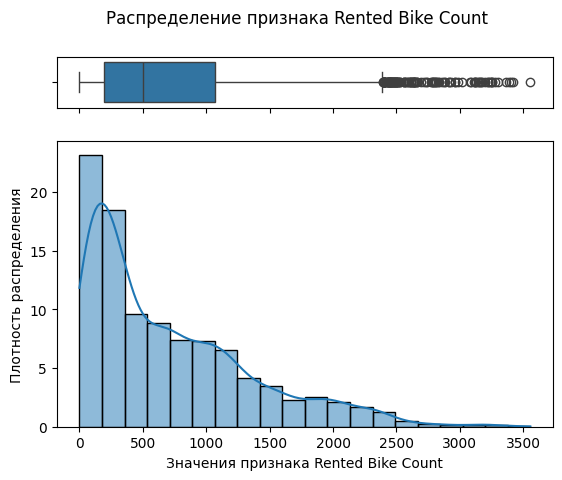

In [52]:

eda_helper = EDAHelper()
eda_helper.box_hist(df, TARGET_COL_NAME, stat='percent')


Медиана количества арендованных велосипедов - 500 шт, тогда как среднее значение - 700. Мы имеем дело со скошенным вправо распределением целевой переменной. Максимальное значение 3500 не выглядит ошибкой заполнения, а может быть реально во время пиковой нагрузки на сервис велопроката.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Ты правильно отметил скошенное вправо распределение и обосновал реалистичность максимальных значений. 

Определим зависимость распределения целевой переменной от сезона:

       Rented Bike Count
count        7008.000000
mean          705.606022
std           646.311790
min             0.000000
25%           190.750000
50%           504.500000
75%          1070.000000
max          3556.000000


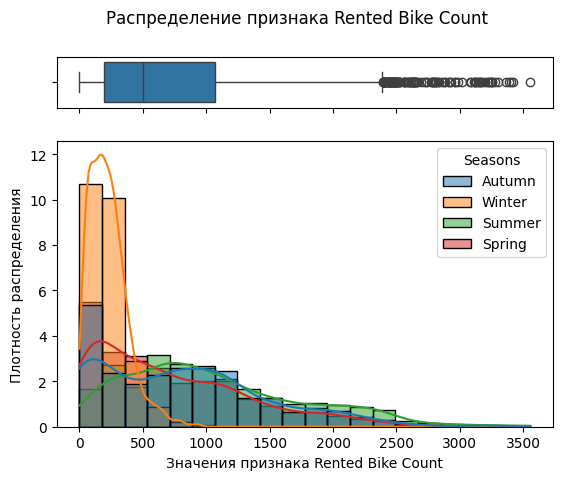

In [53]:
eda_helper.box_hist(df, TARGET_COL_NAME, stat='percent', hue='Seasons')

In [54]:
df.groupby('Seasons')[TARGET_COL_NAME].describe().sort_values('50%', ascending=False)

,count,mean,std,min,25%,50%,75%,max
Seasons,,,,,,,,
Summer,1744.0,1046.247133,690.317212,9.0,539.75,923.0,1462.00,3556.0
Autumn,1770.0,820.644068,654.288199,0.0,228.50,764.0,1191.75,3298.0
Spring,1758.0,725.046075,619.594843,0.0,206.00,578.5,1106.00,3251.0
Winter,1736.0,226.417627,150.824035,3.0,110.00,204.0,306.25,937.0


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Группировка по сезонам с использованием метода `describe()` отлично показывает разницу в распределениях целевой переменной.
</div>

Как и ожидалось в зимний период мы имеем дело с наименьшей нагрузкой на сервис - в среднем арендуется 200 велосипедов. Вероятно это связано с погодными условиями.

Остальные сезоны в целом похожи. Летом велосипеды более популярны (медиана около 1000), что тоже объясняется сезонностью - сказывается приток туристов и погодные условия.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Логичный и обоснованный вывод о влиянии сезона на спрос.
</div>

Визуализируем среднее количество арендованных велосипедов в зависимости от сезона:

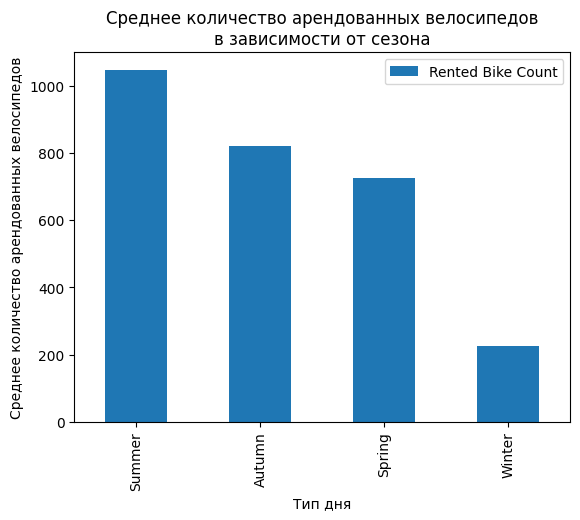

In [55]:
df.groupby(['Seasons']).agg({TARGET_COL_NAME: 'mean'}).sort_values(by=TARGET_COL_NAME, ascending=False).plot(
    kind='bar',
    title='Среднее количество арендованных велосипедов\nв зависимости от сезона',
    xlabel='Тип дня',
    ylabel='Среднее количество арендованных велосипедов'
)
plt.show()

Наглядно представлено значительный перевес аренды велосипедов в теплые сезоны.

### Распределения ключевых признаков

In [56]:
df.select_dtypes(include=['float']).describe()

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,7008.000000,6758.000000,6798.000000,6749.000000,7008.000000,6798.000000,6746.000000,6745.000000
mean,12.812914,58.200503,1.725228,1435.156764,4.021490,0.569885,0.146902,0.074752
std,11.924688,20.340317,1.042956,607.291049,13.033377,0.866142,1.164118,0.438189
min,-17.500000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,3.300000,42.000000,0.900000,936.000000,-4.700000,0.000000,0.000000,0.000000
50%,13.500000,57.000000,1.500000,1691.000000,5.000000,0.010000,0.000000,0.000000
75%,22.400000,74.000000,2.300000,2000.000000,14.800000,0.940000,0.000000,0.000000
max,39.400000,98.000000,7.400000,2000.000000,26.800000,3.520000,35.000000,8.800000


Оценим описательную статистику всех числовых признаков:

Средняя/медианная температура согласуется с реальностью и составляет около 14 градусов. Для юга России это нормально. Минимальная температура в -17 тоже выглядит ок.

Атмосферная влажность равная нулю является выбросом, подобные условия исключительно редки на планете, а такие значения есть в датасете. Как будет показано ниже на гистограмме, таких выбросов немного, можно их игнорировать.

Скорость ветра не вызывает подозрений.
Видимость - вроде тоже близка к адекватным значениям. Точка росы имеет отрицательные значения - это нормально для зимы. Остальные значения так же не вызывают подозрений.


Визуализируем распределения числовых признаков:

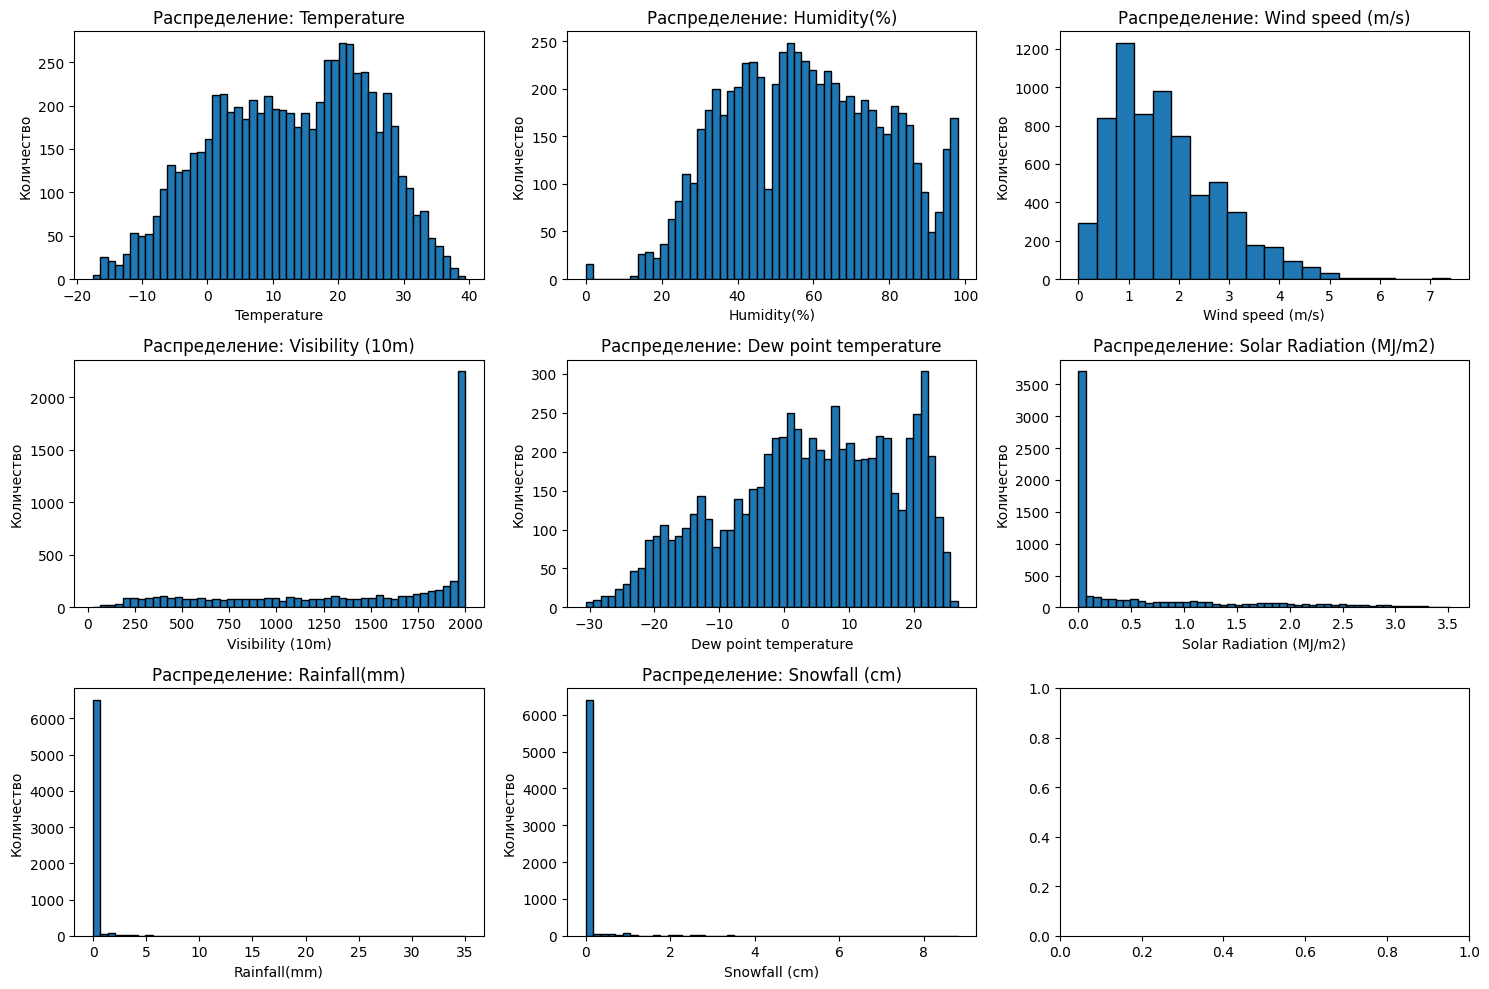

In [57]:
# Визуализация распределений ключевых признаков
fig, axes = plt.subplots(3, 3, figsize=(15, 10))

def hist_at(axes, i, j, column, bins=50):
    axes[i, j].hist(df[column], bins=bins, edgecolor='black')
    axes[i, j].set_title(f'Распределение: {column}')
    axes[i, j].set_xlabel(column)
    axes[i, j].set_ylabel('Количество')

hist_at(axes, 0, 0, 'Temperature')
hist_at(axes, 0, 1, 'Humidity(%)')
hist_at(axes, 0, 2, 'Wind speed (m/s)', bins=20)
hist_at(axes, 1, 0, 'Visibility (10m)')
hist_at(axes, 1, 1, 'Dew point temperature')
hist_at(axes, 1, 2, 'Solar Radiation (MJ/m2)')
hist_at(axes, 2, 0, 'Rainfall(mm)')
hist_at(axes, 2, 1, 'Snowfall (cm)')
# hist_at(axes, 2, 2, 'Rainfall(mm)')


plt.tight_layout()
plt.show()

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Использование подграфиков `subplots` для визуализации распределений всех числовых признаков — отличное решение.

Картина характерна для погодных условий Юга России. Есть как уже отмечалось ранее выбросы во влажности воздуха и есть очень редкие повышенные показатели осадков в виде дождя и снега (что бывает очень редко в данной области), но ими можно принебречь на данном этапе, так как их мало либо они естесственны для специфичных пододных условий.


Оценим зависимость целевой переменной от признаков:

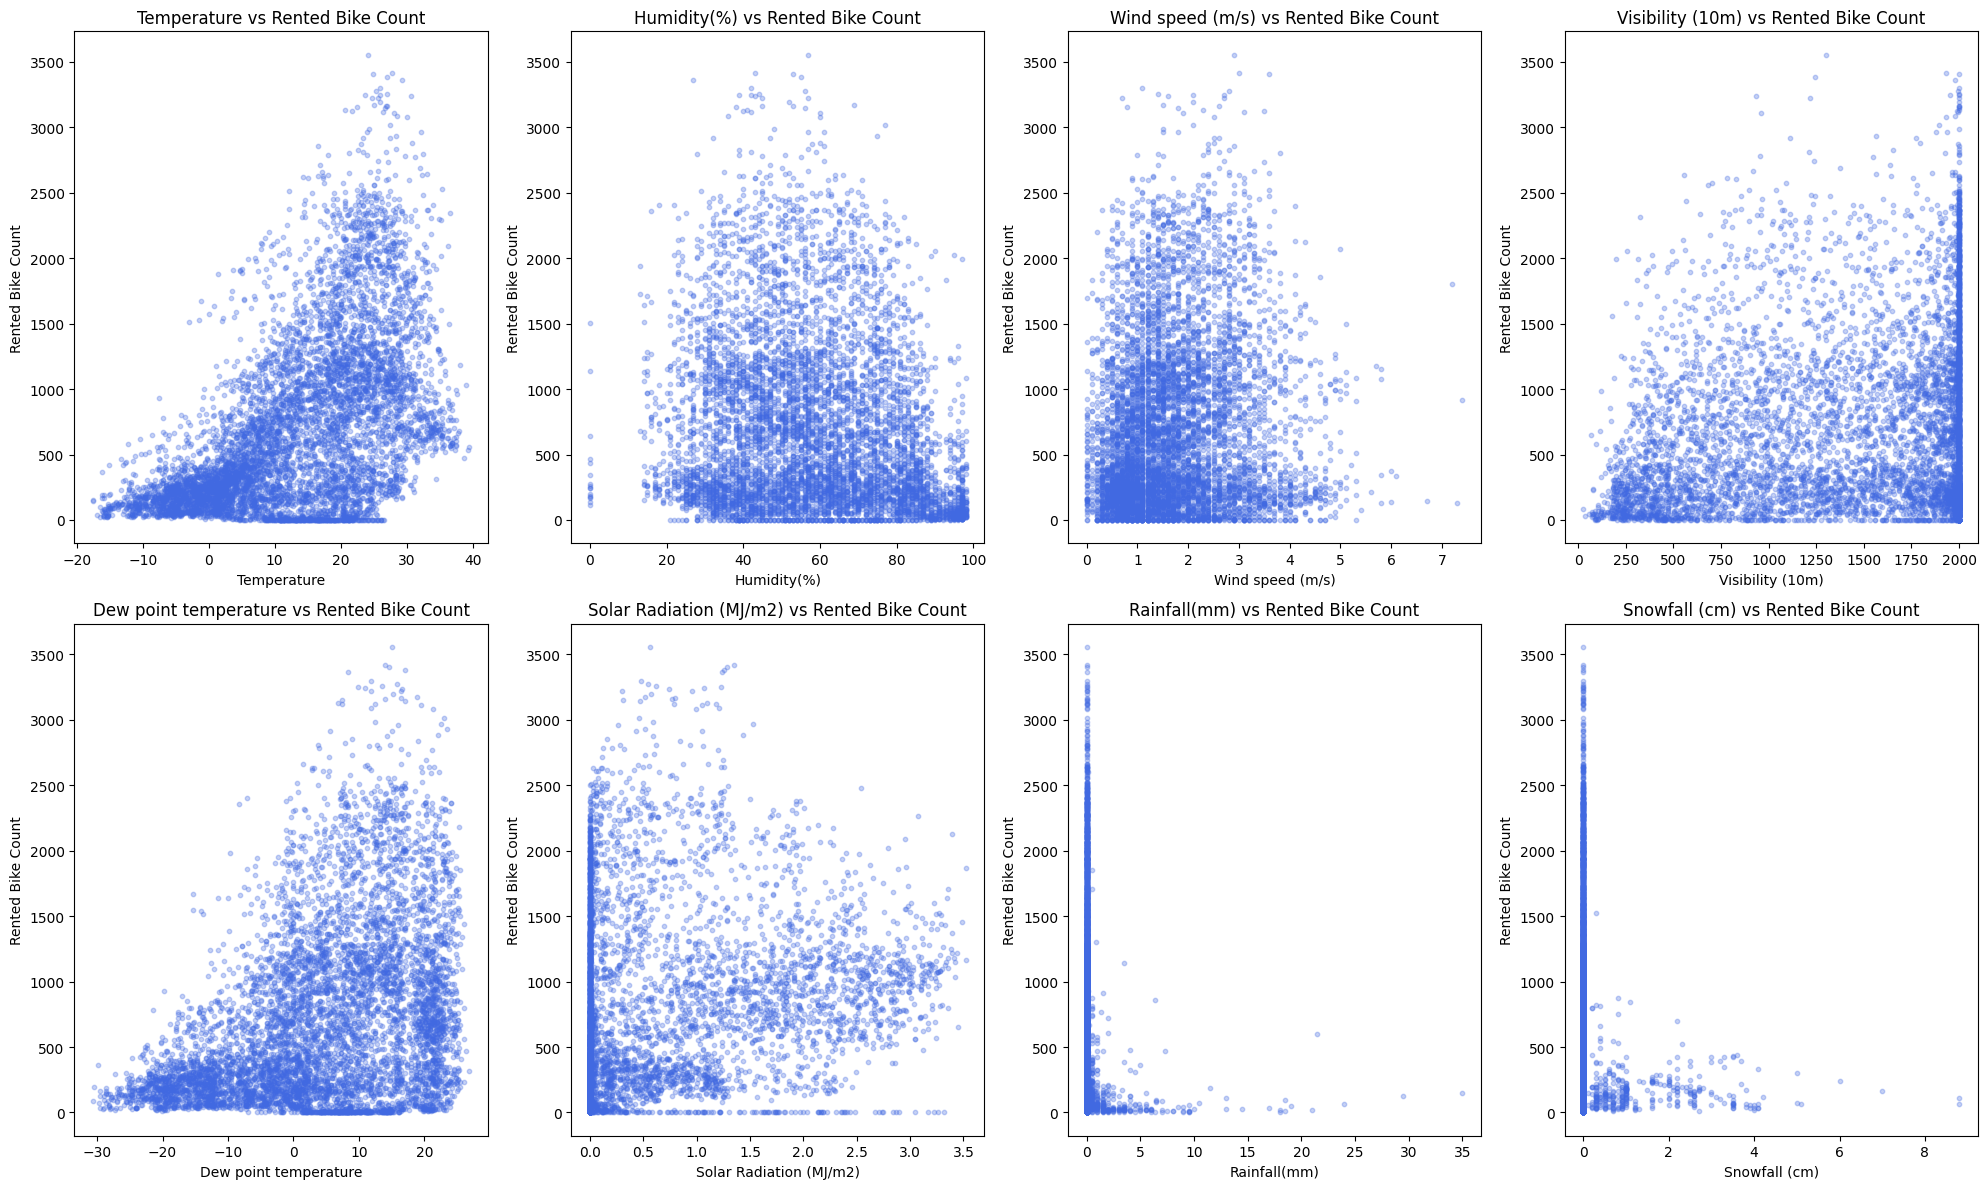

In [58]:
# Список признаков для scatterplot
features = [
    "Temperature",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Visibility (10m)",
    "Dew point temperature",
    "Solar Radiation (MJ/m2)",
    "Rainfall(mm)",
    "Snowfall (cm)"
]

n_features = len(features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(
        df[feature],
        df["Rented Bike Count"],
        alpha=0.3,
        s=10,
        color="royalblue"
    )
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Rented Bike Count")
    axes[i].set_title(feature + " vs Rented Bike Count")

plt.tight_layout()
plt.show()

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Диаграммы рассеяния отлично помогают визуально оценить характер зависимости целевой переменной от признаков.
</div>

Есть харктерные признаки, явно влияющие на аренду велосипедов - это температура воздха и осадки. Зависимость, как видно по диаграммам рассеяния этих признаков нелинейная, то есть линейная модель без соответствующих преобразований и улучшений их уловить не может.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Верное наблюдение о нелинейном характере зависимостей. Это отличное обоснование для выбора более сложных алгоритмов.
</div>

Оценим категориальные признаки:

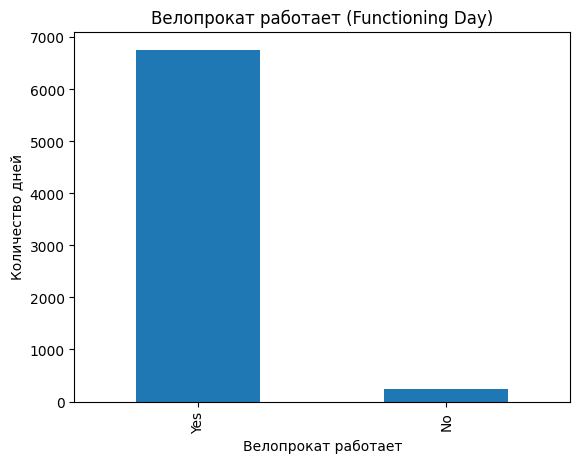

In [59]:
df['Functioning Day'].value_counts().plot(
    kind='bar', title='Велопрокат работает (Functioning Day)',
    ylabel='Количество дней', xlabel='Велопрокат работает')
plt.show()

В большинстве дней велопрокат работает. Очевидно, что когда он не работает, то велосипеды не арендуются. Докажем это:

In [60]:
df.groupby(['Functioning Day']).agg({TARGET_COL_NAME: 'sum'})

,Rented Bike Count
Functioning Day,
No,0
Yes,4944887


Сумма по количеству велосипедов в прокате в дни, когда велопрокат не функционирует, равна нулю.

Рассмотрим значения в колонке Holiday:

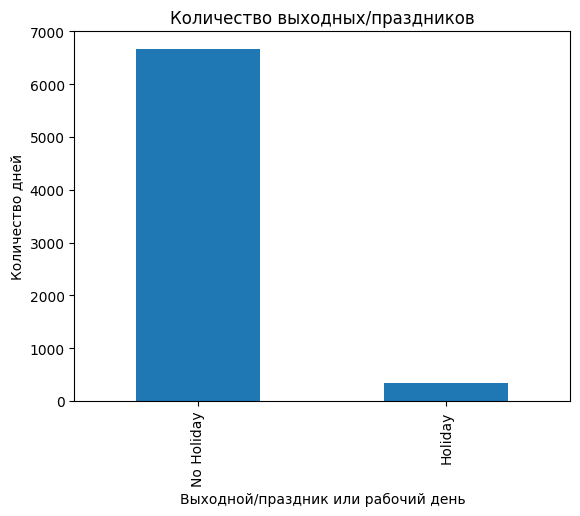

In [61]:
df['Holiday'].value_counts().plot(
    kind='bar',
    title='Количество выходных/праздников',
    ylabel='Количество дней',
    xlabel='Выходной/праздник или рабочий день')
plt.show()

Большинство дней в датасете представлено невыходными днями. Категория выходных представлена исключительно малой группой, в связи с чем влияние данного признака не должно быть значительным для общей картины в тренировочном датасете.

Посмотрим, как соотносится среднее количество арендовнных велосипедов в будни и выходные:

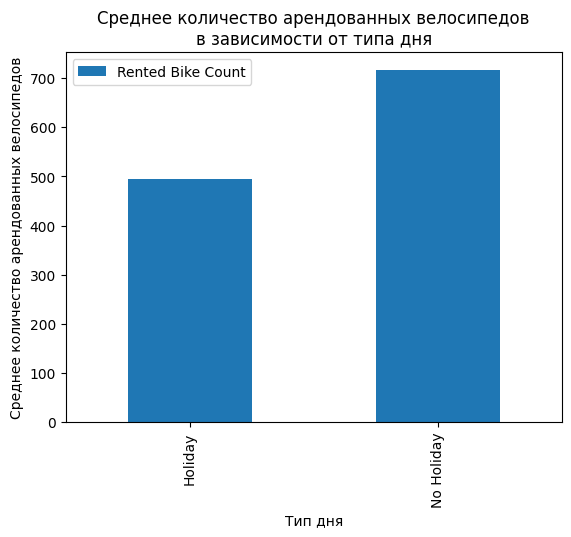

In [62]:
df.groupby(['Holiday']).agg({TARGET_COL_NAME: 'mean'}).plot(
    kind='bar',
    title='Среднее количество арендованных велосипедов\nв зависимости от типа дня',
    xlabel='Тип дня',
    ylabel='Среднее количество арендованных велосипедов'
)
plt.show()



В среднем велосипеды чаще используются не в выходные дни, а в будни.

Посмотрим на признаки, относящиеся к времени суток аренды велосипедов.

Для начала проверим, что данный категориальный признак правильно закодирован, то есть в датасете отсутствуют строчки, в которых бы стоял флаг true в нескольких столбцах, относящихся к разному времени суток.

In [63]:
mask_check_errors = (
    (df['Time_Period_Evening'].astype(int) \
     + df['Time_Period_Late Evening'].astype(int)
     + df['Time_Period_Morning'].astype(int)
    + df['Time_Period_Night'].astype(int)) > 1
)
df[mask_check_errors]

,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count


Некорректных данных в столбцах со временем суток аренды не встречается.

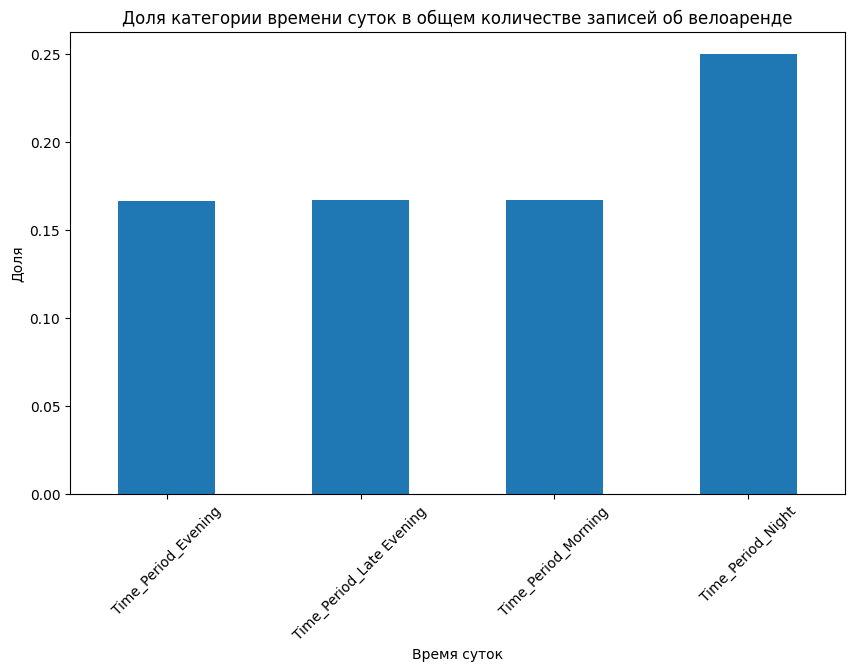

In [64]:
time_stats = df[[
    'Time_Period_Evening',
    'Time_Period_Late Evening',
    'Time_Period_Morning',
    'Time_Period_Night',
]].agg(['sum', 'mean']).T
time_stats.plot(
    kind='bar',
    figsize=(10, 6),
    y='mean',
    title='Доля категории времени суток в общем количестве записей об велоаренде',
    xlabel='Время суток',
    ylabel='Доля',
    rot=45,
    legend=False,
)
plt.show()

В датасете представлено примерно по 17% записей в следующие периоды суток: утро, поздний вечер, вечер. 25% - в ночное время и оставшиеся 25% записей относятся к дневной аренде.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Четко описано распределение записей по времени суток на основе графика.
</div>

Для удобства анализа признака времени суток, соберем его снова в категориальный столбец:

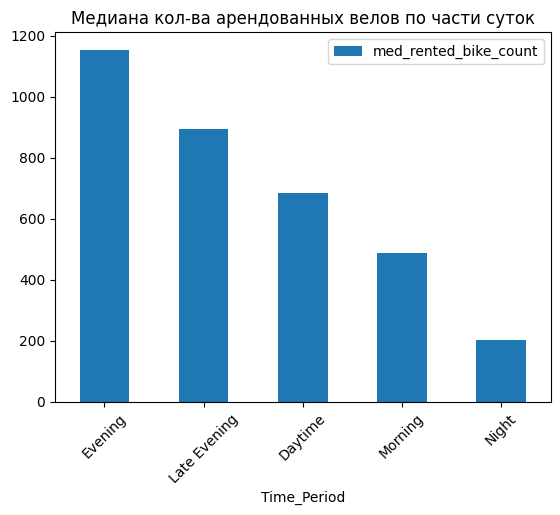

In [65]:
def get_time_period(row):
    if row['Time_Period_Evening']:  return 'Evening'
    if row['Time_Period_Late Evening']: return 'Late Evening'
    if row['Time_Period_Morning']:  return 'Morning'
    if row['Time_Period_Night']:    return 'Night'
    return 'Daytime'

df['Time_Period'] = df.apply(lambda x: get_time_period(x), axis=1)

df.groupby('Time_Period').agg(
    med_rented_bike_count = ('Rented Bike Count', 'median'),
).round(1).reset_index() \
    .sort_values('med_rented_bike_count', ascending=False) \
    .plot(x='Time_Period', y='med_rented_bike_count', rot=45,
          kind='bar', title='Медиана кол-ва арендованных велов по части суток')
plt.show()

# удалим проанализированный столбец
df.drop('Time_Period', axis=1, inplace=True)


<div style="background-color: #fff3cd; color: #856404; padding: 15px; border-radius: 4px; border: 1px solid #ffeeba;">
<b>Комментарий ревьюера v1:</b>

Использование метода `apply()` с `lambda` здесь избыточно и работает медленно на больших объемах данных. Можно было использовать метод `idxmax()` по столбцам времени суток: `df[['Time_Period_Evening', ...]].idxmax(axis=1)`.
</div>

Несмотря на то, что записей о дневных и ночных арендах больше всего, медианное количество арендованных велосипедов в зависимости от периода суток говорит, что самое интенсивное время велопроката - это вечер, поздний вечер и день. 

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Правильный вывод о пиковых часах аренды велосипедов.
</div>

### Корреляционный анализ

/Users/ngsmirnov/nikki/projects/practicum/sprint14_knn_tree/.venv/lib/python3.12/site-packages/phik/data_quality.py:59: UserWarning: The number of unique values of variable Rented Bike Count is large: 2024. Are you sure this is not an interval variable? Analysis for pairs of variables including Rented Bike Count can be slow.
  warnings.warn(


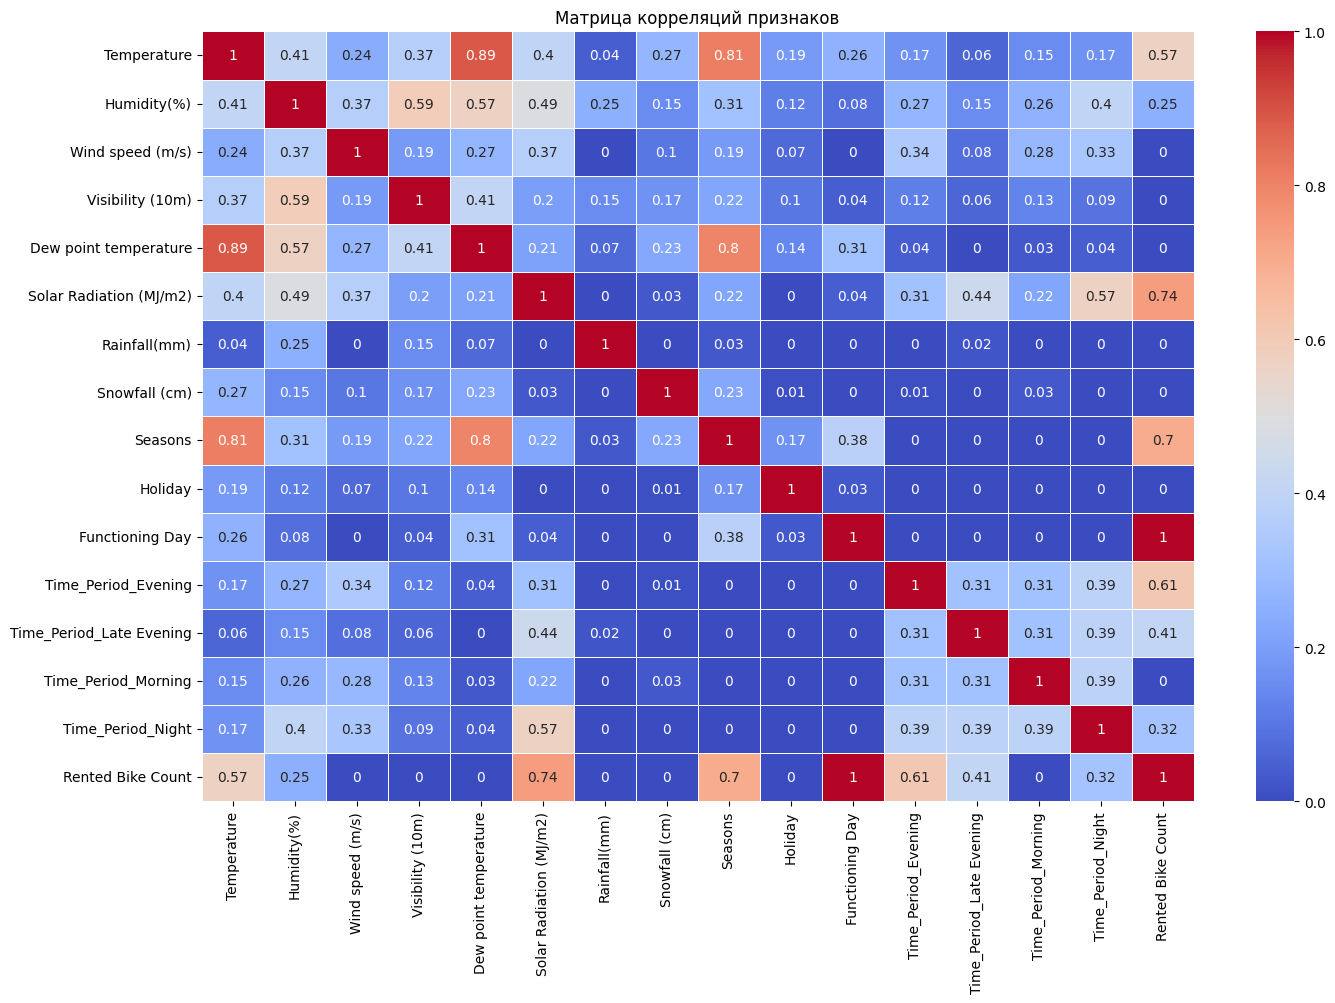

In [66]:
interval_cols = df.select_dtypes(include=['float64']).columns
full_corr_matrix = df.phik_matrix(interval_cols=interval_cols)
corr_displayer = CorrelationDisplayer(full_corr_matrix)
corr_displayer.draw_corr_matrix_full()

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Использование `phik_matrix` — отличный выбор для поиска нелинейных зависимостей между признаками.
</div>

Корреляционная матрица показывает сильную корреляцию целевой переменной с признаком Function Day, Solar Radiation, Seasons. Умеренная корреляция с вечерним временем суток и температурой.
Все они так или иначе обусловлены естесственными связями погодных условий.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Ты верно выделил наиболее коррелирующие признаки на основе матрицы.
</div>

Оценим более точечно корреляцию признаков и целевой переменной:

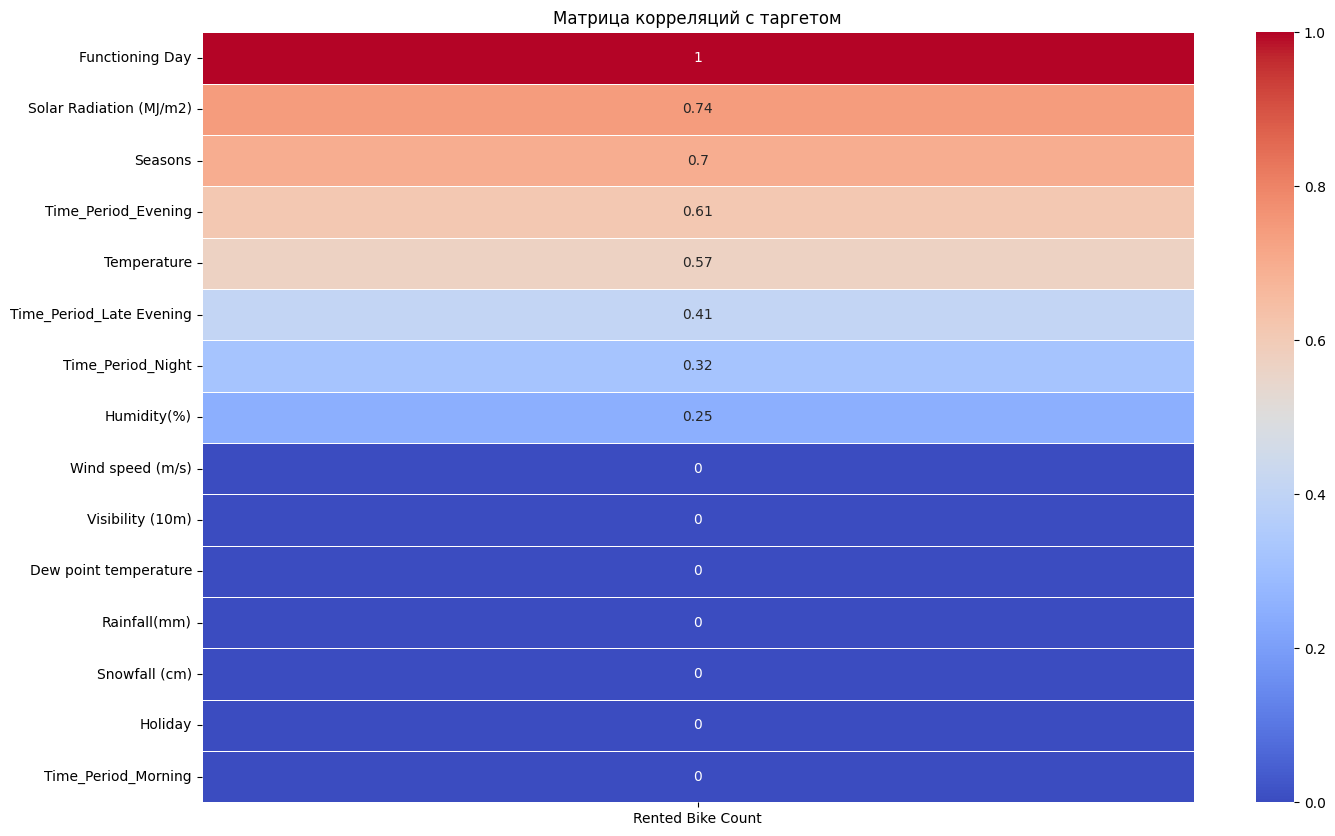

In [67]:
corr_displayer.draw_corr_matrix_with_target(TARGET_COL_NAME)

Очевидно количество арендованных велосипедов скоррелировано с Function Day, так как в этот день аренда не работает.
Солнечная радиация и Сезон слабо скоррелированы друг с другом, но при этом сильно влияют на целевую переменную.

<a id="baseline"></a>

## Обучение базовых моделей

Перед обучение моделей выделим признаки обучающей выборки и целевую переменную. Для теста заказчик предоставил отдельный файл с датасетом, его тоже обработаем для формирования тестовой выборки:

In [68]:
X_train = df.drop(columns=TARGET_COL_NAME)
y_train = df[TARGET_COL_NAME]

X_test = df_test.drop(columns=TARGET_COL_NAME)
y_test = df_test[TARGET_COL_NAME]

# Проверим размерности выборок:
print(f'Размер тренировочной матрицы признаков  {X_train.shape}')
print(f'Размер тренировочного вектора-таргета   {y_train.shape}')
print(f'Размер тестовой матрицы признаков       {X_test.shape}')
print(f'Размер тестового вектора-таргета        {y_test.shape}')

Размер тренировочной матрицы признаков  (7008, 15)
Размер тренировочного вектора-таргета   (7008,)
Размер тестовой матрицы признаков       (1752, 15)
Размер тестового вектора-таргета        (1752,)


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Разделение на признаки и целевую переменную выполнено корректно для обеих выборок.
</div>

**Шаг 3. Обучение новых моделей**

kNN и деревья решений могут уловить нелинейные зависимости, недоступные линейной регрессии. Пора это проверить!

1. Подготовьте пайплайн для каждой модели:
    * Выполните предобработку данных.
    * Инициализизируйте регрессионные модели kNN и дерево решений.
4. Настройте базовые параметры моделей — например, `n_neighbors` для kNN, `max_depth` для дерева.

**Совет:**

Начинайте с базовых параметров, чтобы убедиться, что пайплайн работает. Оптимизацию параметров вы сделаете на следующем шаге.

---



Обучим базовые модели kNN и решаюшее дерево, но предварительно произведем предобработку признаков в Pipeline.

Для kNN исключительно важно, чтобы признаки были отмасштабированы. Пайплайн для решающего дерева будет чуть другим - ему масштабирование признаков не нужно. В обоих пайплайнах необходимо обработать пропуски.

In [69]:
knn_num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
tree_num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=-999999)),
])
cat_pipeline = Pipeline([
    (
        'ohe', OneHotEncoder(drop='first',
                             sparse_output=False,
                             handle_unknown='ignore')
    )
])

num_features = df.select_dtypes(include=['float']).columns.to_list()
cat_features = df.select_dtypes(include=['object']).columns.to_list()
# комментарий студента: не поддерживается текущей версией pandas
#cat_features = df.select_dtypes(include=['str']).columns.to_list()

knn_preprocessor = ColumnTransformer(
    transformers=[
        ('num', knn_num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ],
    remainder='passthrough'
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num', tree_num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ],
    remainder='passthrough'
)

knn_pipeline = Pipeline([
    ('preprocessor', knn_preprocessor),
    ('knn', KNeighborsRegressor())
])

tree_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('tree', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

pipelines = {
    'knn': knn_pipeline,
    'tree': tree_pipeline,
}

/var/folders/qy/vrhgk4653zx3pp81pb5hn8500000gn/T/ipykernel_50621/2352765615.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = df.select_dtypes(include=['object']).columns.to_list()


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Верное создание `Pipeline` и `ColumnTransformer`

Определим метрики качества и обучим модели на кросс-валидации:

In [70]:
scoring = ['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2']
skf =  KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metrics_df_list = list()

model_train_helper = ModelTrainHelper()
cv_results_base = model_train_helper.do_cross_validation(
    pipelines,
    X_train, y_train,
    scoring,
    metrics_df_list,
    return_train_score=True,
    cv=skf,
)

# выведем результаты обучения вместе с метриками линейной модели
baseline_results = pd.DataFrame.from_dict([{
    'model_name': 'linear',
    'r2': baseline_r2,
    'mean_absolute_error': baseline_mae,
    'root_mean_squared_error': baseline_rmse,
}])
baseline_results.set_index('model_name', inplace=True)

pd.concat([
    cv_results_base,
    baseline_results,
])

,mean_absolute_error,r2,root_mean_squared_error
model_name,,,
tree (train),-0.000000,1.000000,-0.000000
knn (train),178.734145,0.824370,270.829614
knn,221.659327,0.737499,330.997783
tree,245.039325,0.627925,393.730003
linear,312.599334,0.586072,411.564089


Модель kNN показывает почти на 20% лучше результат, чем базовая линейная модель по метрике RMSE.
Метрика R2 говорит нам, что knn объясняет 73% дисперсии целевой переменной, тогда как линейнай модель только 59%.

Решающее дерево тоже лучше по всем метрикам, чем старая модель, но все же уступает knn.

Метрики, которые получены на тренировочной выборке говорят о сильном переобучении DecisionTree под тренировочный датасет - метрики ошибок равны нулю. Knn тоже переобучается, так как метрики значительно лучше на трейн выборке.

Регуляризация с помощью гиперпараметров при подборе поможет избежать переобучение и повысит качество конечной модели.

<a id="hyperparameters"></a>
## Подбор гиперпараметров с Optuna

**Шаг 4. Подбор гиперпараметров с Optuna**

Компания хочет точную модель. Optuna поможет найти лучшие гиперпараметры для kNN и дерева, чтобы снизить ошибки прогноза.


1. Определите функцию цели для Optuna.

2. Настройте диапазоны гиперпараметров.

3. Запустите оптимизацию и сохраните лучшие параметры.

**Совет:**

Не бойтесь сначала экспериментировать с небольшими диапазонами, а потом расширять их, если модель не уловит зависимости.

---



### Оптимизация DecisionTree

Определим границы варьирования параметров моделей и запустим Optuna:

In [71]:
optuna_helper = OptunaHelper(
    X_train, y_train,
    cv=skf,
)
scorer_func = make_scorer(root_mean_squared_error, greater_is_better=False)

def tree_params_func(trial):
    return {
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 100),
        'criterion': trial.suggest_categorical('criterion', ['squared_error', 'absolute_error']),
    }

def tree_estimator_func(params):
    return Pipeline([
        ('preprocessor', tree_preprocessor),
        ('model', DecisionTreeRegressor(random_state=RANDOM_STATE, **params))
    ])

tree_study = optuna_helper.fit_study(
    tree_params_func, tree_estimator_func, scorer_func, n_trials=30, visualize=True)

print('=== Решающее дерево ===')
print('Наилучшие гиперпараметры:', tree_study.best_params)
print(f'RMSE: {-tree_study.best_value:.2f}')

[I 2026-04-24 15:46:20,215] A new study created in memory with name: no-name-61e28680-3a0f-49c6-a51d-a4f257a35211
[I 2026-04-24 15:46:20,345] Trial 0 finished with value: -335.14053079405846 and parameters: {'max_depth': 7, 'min_samples_split': 54, 'criterion': 'squared_error'}. Best is trial 0 with value: -335.14053079405846.
[I 2026-04-24 15:46:24,034] Trial 1 finished with value: -332.0334080742475 and parameters: {'max_depth': 16, 'min_samples_split': 81, 'criterion': 'absolute_error'}. Best is trial 1 with value: -332.0334080742475.
[I 2026-04-24 15:46:24,204] Trial 2 finished with value: -331.3665611030041 and parameters: {'max_depth': 17, 'min_samples_split': 29, 'criterion': 'squared_error'}. Best is trial 2 with value: -331.3665611030041.
[I 2026-04-24 15:46:24,373] Trial 3 finished with value: -324.7373369012719 and parameters: {'max_depth': 24, 'min_samples_split': 42, 'criterion': 'squared_error'}. Best is trial 3 with value: -324.7373369012719.
[I 2026-04-24 15:46:24,512] 

=== Решающее дерево ===
Наилучшие гиперпараметры: {'max_depth': 10, 'min_samples_split': 69, 'criterion': 'squared_error'}
RMSE: 319.38


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Настройка `Optuna` выполнена очень грамотно, диапазоны гиперпараметров заданы адекватно.
</div>

Оптимизация параметров модели решающего дерева с поомщью Optuna привела к улучшению ключевой метрики на 19%.
Наилучшие гиперпараметры `{'max_depth': 10, 'min_samples_split': 69, 'criterion': 'squared_error'}`

### Оптимизация Knn

Теперь оптимизируем kNN:

In [72]:
def knn_params_func(trial):
    return {
        'metric': trial.suggest_categorical('metric', ['minkowski']),
        'p': trial.suggest_int('p', 1, 2), # 1 - манхэттенское. 2 - эвклидово
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 30),
    }

def knn_estimator_func(params):
    return Pipeline([
        ('preprocessor', knn_preprocessor),
        ('model', KNeighborsRegressor(**params))
    ])

knn_study = optuna_helper.fit_study(
    knn_params_func, knn_estimator_func, scorer_func, n_trials=20, visualize=True)

print('=== Knn ===')
print('Наилучшие гиперпараметры:', knn_study.best_params)
print(f'RMSE: {-knn_study.best_value:.2f}')

[I 2026-04-24 15:46:45,994] A new study created in memory with name: no-name-022ce90d-8d29-4f19-bef1-52b285731b5b
[I 2026-04-24 15:46:46,189] Trial 0 finished with value: -329.3743364502542 and parameters: {'metric': 'minkowski', 'p': 1, 'n_neighbors': 17}. Best is trial 0 with value: -329.3743364502542.
[I 2026-04-24 15:46:46,380] Trial 1 finished with value: -328.3197999473359 and parameters: {'metric': 'minkowski', 'p': 1, 'n_neighbors': 4}. Best is trial 1 with value: -328.3197999473359.
[I 2026-04-24 15:46:46,559] Trial 2 finished with value: -336.13529468296093 and parameters: {'metric': 'minkowski', 'p': 1, 'n_neighbors': 25}. Best is trial 1 with value: -328.3197999473359.
[I 2026-04-24 15:46:46,745] Trial 3 finished with value: -328.3516660615484 and parameters: {'metric': 'minkowski', 'p': 1, 'n_neighbors': 16}. Best is trial 1 with value: -328.3197999473359.
[I 2026-04-24 15:46:46,871] Trial 4 finished with value: -330.80489226251194 and parameters: {'metric': 'minkowski', '

=== Knn ===
Наилучшие гиперпараметры: {'metric': 'minkowski', 'p': 1, 'n_neighbors': 9}
RMSE: 322.31


Knn также вырос в качестве после подбора гиперпараметров на 3% по ключевой метрике.

<a id="final-model"></a>
## Обучение финальной модели

Теперь обучим финальные модели на всей тренировочной выборке с оптимизированными гиперпараметрами:

In [73]:
pipelines = {
    'knn (opt)': Pipeline([
        ('preprocessor', knn_preprocessor),
        ('model', KNeighborsRegressor(**knn_study.best_params))
    ]),
    'tree (opt)': Pipeline([
        ('preprocessor', tree_preprocessor),
        ('model', DecisionTreeRegressor(random_state=RANDOM_STATE, **tree_study.best_params))
    ])
}

cv_results_opt = model_train_helper.do_cross_validation(
    pipelines,
    X_train, y_train,
    scoring,
    return_train_score=True,
    cv=skf,
)



In [74]:
df_res_train = pd.concat([
    cv_results_opt,
    cv_results_base,
    baseline_results
])
df_res_train

,mean_absolute_error,r2,root_mean_squared_error
model_name,,,
tree (opt) (train),190.074131,0.804429,285.754010
knn (opt) (train),194.483547,0.800865,288.383434
tree (opt),212.589152,0.755535,319.382609
knn (opt),218.946248,0.751092,322.314877
tree (train),-0.000000,1.000000,-0.000000
knn (train),178.734145,0.824370,270.829614
knn,221.659327,0.737499,330.997783
tree,245.039325,0.627925,393.730003
linear,312.599334,0.586072,411.564089


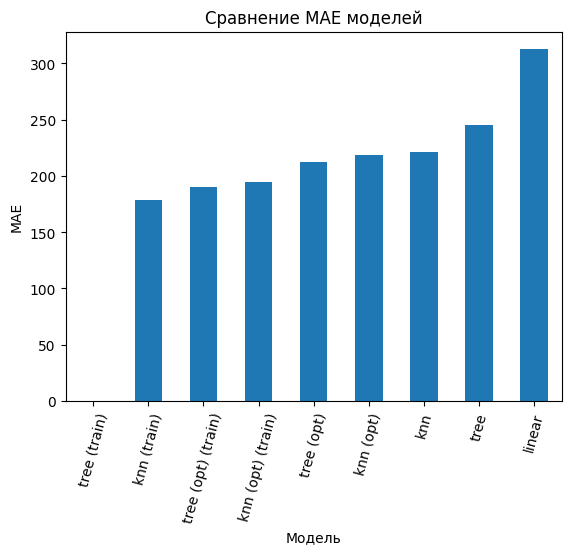

In [75]:
df_res_train.sort_values(by=['mean_absolute_error'])['mean_absolute_error'].plot(
    kind='bar',
    title='Сравнение MAE моделей',
    xlabel='Модель',
    ylabel='MAE',
    rot=75,
)
plt.show()

По средней абсолютной ошибке лучшей моделью стало решающее дерево, оптимизированное с помощью Optuna.

Оценим важность признаков у лучшей модели:

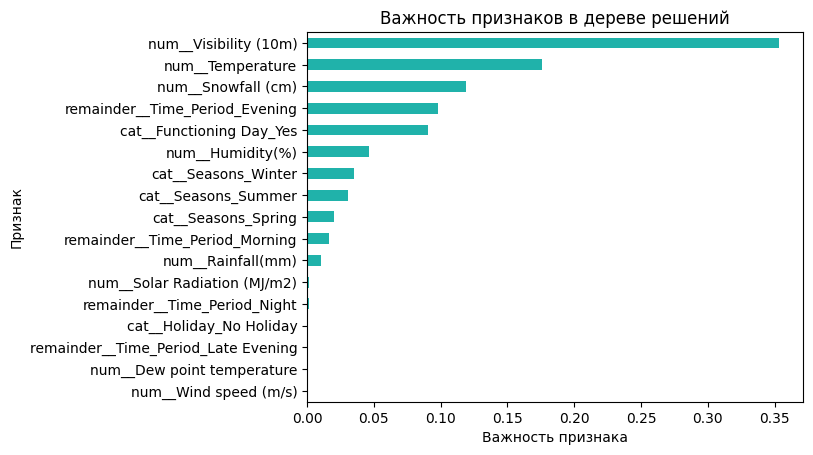

In [76]:
pipe = pipelines['tree (opt)'].fit(X_train, y_train)
preprocessor = pipe.named_steps['preprocessor']
tree = pipe.named_steps['model']


# Получение и сортировка по возрастанию важности признаков
importances = pd.Series(
    tree.feature_importances_,
    index=preprocessor.get_feature_names_out()
)
importances = importances.sort_values(ascending=True)

# Если колонки преобразованы, то так универсальнее:
importances = pd.DataFrame({
         # Названия признаков
        "feature": importances.index,
        # Значения важности признаков
        "importance": tree.feature_importances_,
}).sort_values(by=['importance'], ascending=True)

importances.set_index('feature', inplace=True)
# # Визуализация
importances.plot(kind='barh', color='lightseagreen',
                 title='Важность признаков в дереве решений',
                 xlabel='Важность признака',
                 ylabel='Признак',
                 legend=False,
                 )
plt.show()

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Извлечение важности признаков из `Pipeline` выполнено верно. 

Числовые фичи Visibility, Temperature, Snowfall оказались самыми важными в моделе дерева решений.

<a id="final-report"></a>

## Выводы по выбору модели

| Модель | MAE | RMSE | R² |
|---|---|---|---|
| Линейная регрессия (baseline) | 312.60 | 411.56 | 0.586 |
| kNN (базовый) | 221.66 | 331.00 | 0.737 |
| Дерево решений (базовое) | 245.04 | 393.73 | 0.628 |
| kNN (Optuna) | 218.95 | 322.32 | 0.751 |
| **Дерево решений (Optuna)** | **212.59** | **319.38** | **0.756** |


Лучшей по всем метрикам стало дерево решений с подобранными гиперпараметрами ('max_depth': 10, 'min_samples_split': 69, 'criterion': 'squared_error'):

MAE = 212 - модель ошибается в среднем на ~212 велосипедов, тогда как baseline ошибался на 313. Улучшение - 32%.
R² = 0.756 против 0.586 у baseline - модель объясняет 76% дисперсии спроса.
RMSE = 319.38 против 411.56 у baseline - улучшение на 23%.
Подбор гиперпараметров через Optuna дал дереву прирост RMSE на ~20% (с 393.73 до 319.38). Для kNN прирост скромнее - ~3% (с 331.00 до 322.32).


По `feature_importances_` дерева решений наиболее важными оказались `Visibility` (видимость), `Snowfall` (снегопад) и `Temperature` (температура). Это логично с точки зрения бизнеса: при выпадении осадков или плохой видимости люди не берут велосипеды, а в теплую сухую погоду - спрос резко растет. Солнечная радиация и сезон тоже сильно коррелируют с таргетом, что подтвердил корреляционный анализ, однако при построении дерева радиация показала себя несильными признаком.

Переход с линейной регрессии на дерево решений с оптимизацией гиперпараметров оправдан - средняя абсолютная ошибка модели снизилась с 313 до 212 велосипедов! Нелинейные модели лучше улавливают зависимость спроса от погоды, особенно пороговые эффекты (например, резкое падение аренды при снегопаде или морозе).

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Итоговая таблица и выводы также верные.

<a id="save-model"></a>

## Подготовка артефактов модели для внедрения

### Обучение финальной модели на тестовой выборке

In [77]:
final_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('tree', DecisionTreeRegressor(random_state=RANDOM_STATE, **tree_study.best_params))
])
final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)

print(f'final MAE:  {final_mae:.2f}')
print(f'final RMSE: {final_rmse:.2f}')
print(f'final R2:   {final_r2:.3f}')

final MAE:  207.90
final RMSE: 308.71
final R2:   0.767


<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">
<b>Комментарий ревьюера v1:</b>

Оценка на тестовой выборке проведена корректно, утечек данных нет.
</div>

На тестовой выборке финальная модель показала еще лучшие результаты:
- final MAE:  207.90
- final RMSE: 308.71
- final R2:   0.767

Сохраним модель для использования в продакшене:

In [78]:
VERSION=1.0
date = datetime.now().strftime('%Y_%m_%d')
model_name = f"bikesouth_demand_prediction_v{VERSION}_{date}.joblib"

ALL_FEATURES = df.columns.tolist()

metadata = {
    'model_version': f'{VERSION}',
    'training_date': f'{date}',
    'final_mae': final_mae,
    'final_rmse': final_rmse,
    'final_r2': final_r2,
    'features': ALL_FEATURES,
}

joblib.dump(
    {
        'model': final_pipeline,
        'metadata': metadata,
    },
    model_name,
)

['bikesouth_demand_prediction_v1.0_2026_04_24.joblib']

Проверим работоспособность сохраненной модели, загрузив ее и выполнив инференс.

In [79]:
loaded_model = joblib.load(f'{model_name}')
# Оценивать будем произвольную запись из тестового датасета
record_serialized = df_test.iloc[RANDOM_STATE].to_json(indent=2)
print(record_serialized)

{
  "Temperature":24.3,
  "Humidity(%)":37.0,
  "Wind speed (m\/s)":2.3,
  "Visibility (10m)":1583.0,
  "Dew point temperature":8.6,
  "Solar Radiation (MJ\/m2)":2.22,
  "Rainfall(mm)":0.0,
  "Snowfall (cm)":0.0,
  "Seasons":"Spring",
  "Holiday":"No Holiday",
  "Functioning Day":"Yes",
  "Time_Period_Evening":false,
  "Time_Period_Late Evening":false,
  "Time_Period_Morning":false,
  "Time_Period_Night":false,
  "Rented Bike Count":1579
}


In [80]:
record_df = pd.DataFrame.from_dict([{
  "Temperature":24.3,
  "Humidity(%)":37.0,
  "Wind speed (m/s)":2.3,
  "Visibility (10m)":1583.0,
  "Dew point temperature":8.6,
  "Solar Radiation (MJ/m2)":2.22,
  "Rainfall(mm)":0.0,
  "Snowfall (cm)":0.0,
  "Seasons":"Spring",
  "Holiday":"No Holiday",
  "Functioning Day":"Yes",
  "Time_Period_Evening":False,
  "Time_Period_Late Evening":False,
  "Time_Period_Morning":False,
  "Time_Period_Night":False,
#   "Rented Bike Count":1579
}])
resut = loaded_model['model'].predict(record_df)
print(f'Предсказанное значение: {resut}')
print(f'Реальное значение: 1579')

Предсказанное значение: [1213.63979417]
Реальное значение: 1579


Загруженная модель работает и может быть использована в производственных процессах.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Комментарий ревьюера v1:</b>
    
Ты проделал отличную работу по построению модели прогнозирования спроса для сервиса аренды велосипедов!

Особенно впечатляет твой системный подход к задаче регрессии: чёткая структура исследования, обоснованный выбор метрик качества (RMSE/MAE) и грамотное использование sklearn Pipeline для инкапсуляции предобработки. Отдельный плюс — за глубокий EDA: ты не просто посмотрел на данные, но и выявил нелинейные зависимости, которые и обосновали переход от простых линейных моделей к более сложным алгоритмам.

Замечательно, что ты уделил внимание интерпретируемости решения. Анализ важности признаков (Feature Importance) дает бизнесу понимание того, какие факторы (температура, сезонность, время суток) реально драйвят спрос. Это превращает "черный ящик" модели в полезный аналитический инструмент. Также стоит отметить корректное использование кросс-валидации и подбора гиперпараметров — ты честно сравнил модели и выбрал лучшую на основе цифр, а не интуиции.